# Vision Language Model (VLM) — QLoRA Fine-Tuning
## Document-to-Markdown Generation

**Objective:** Fine-tune Qwen2-VL-2B-Instruct using QLoRA to convert document images into structured markdown.

**Platform:** Kaggle (GPU T4 x2) | **Model:** Qwen/Qwen2-VL-2B-Instruct | **Technique:** QLoRA (4-bit quantization + LoRA adapters)

---
## Part 0: Environment Setup

In [ ]:
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

for pkg in [
    "transformers>=4.45.0", "peft>=0.13.0", "bitsandbytes>=0.43.0",
    "accelerate>=0.34.0", "datasets>=2.20.0", "qwen-vl-utils",
    "torchvision", "pillow", "tqdm", "matplotlib", "rouge_score"
]:
    install(pkg)

print("All packages installed.")

In [56]:
import os, json, random, importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset

import transformers
from transformers import (
    AutoProcessor, BitsAndBytesConfig, TrainingArguments, Trainer, EarlyStoppingCallback
)
from transformers import Qwen2VLForConditionalGeneration
from peft import LoraConfig, TaskType, get_peft_model, prepare_model_for_kbit_training, PeftModel
from datasets import Dataset as HFDataset
from sklearn.model_selection import train_test_split

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

print(f"PyTorch:        {torch.__version__}")
print(f"Transformers:   {transformers.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")

PyTorch:        2.10.0+cu128
Transformers:   5.0.0
CUDA available: True
  GPU 0: Tesla T4
  GPU 1: Tesla T4


---
## Part 1: Dataset Exploration

In [57]:
import os

DATASET_PATH = "/kaggle/input/datasets/zphilip/nougat-training-dataset-example"  

def pair_image_markdown(dataset_path):
    img_exts = {'.png', '.jpg', '.jpeg'}
    md_exts  = {'.mmd', '.md', '.txt'}

    pairs = []

    for root, _, files in os.walk(dataset_path):
        dir_stems = {}
        for fname in files:
            stem, ext = os.path.splitext(fname)
            ext = ext.lower()
            if ext not in img_exts and ext not in md_exts:
                continue
            if stem not in dir_stems:
                dir_stems[stem] = {}
            dir_stems[stem][ext] = os.path.join(root, fname)


        for stem, exts in dir_stems.items():
            img_path = next((exts[e] for e in img_exts if e in exts), None)
            md_path  = next((exts[e] for e in md_exts  if e in exts), None)

            if img_path and md_path:
                with open(md_path, 'r', encoding='utf-8', errors='ignore') as f:
                    content = f.read().strip()
                if len(content) > 50:        
                    rel = os.path.relpath(root, dataset_path)
                    unique_stem = rel.replace(os.sep, '_') + '_' + stem
                    pairs.append({
                        'image_path': img_path,
                        'markdown':   content,
                        'stem':       unique_stem
                    })

    return pairs

all_pairs = pair_image_markdown(DATASET_PATH)
print(f"Total paired samples found: {len(all_pairs)}")

Total paired samples found: 14206


Total pairs available: 14206

Sample 1 | Document ID: 0508_cond-mat0508322_29
Image Path: /kaggle/input/datasets/zphilip/nougat-training-dataset-example/0508/cond-mat0508322/29.png

Image: 816x1056px  Aspect ratio: 0.77


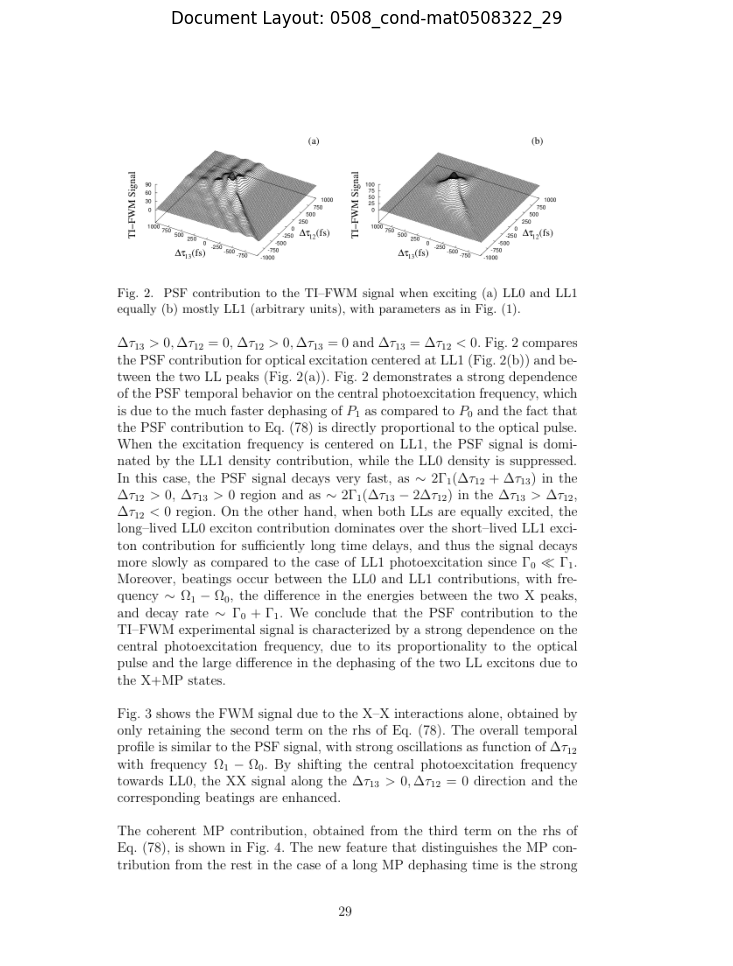


Markdown Preview:
--------------------------------------------------------------------------------
ked along the directions \(\Delta\tau_{13}>0,\Delta\tau_{12}=0\),
\(\Delta\tau_{12}>0,\Delta\tau_{13}=0\) and \(\Delta\tau_{13}=\Delta\tau_{12}<0\). Fig. 2 compares
the PSF contribution for optical excitation centered at LL1 (Fig. 2(b)) and between the two LL peaks
(Fig. 2(a)). Fig. 2 demonstrates a strong dependence of the PSF temporal behavior on the central
photoexcitation frequency, which is due to the much faster dephasing of \(P_{1}\) as compared to
\(P_{0}\) and the fact that the PSF contribution to Eq. (78) is directly proportional to the optical
pulse. When the excitation frequency is centered on LL1, the PSF signal is dominated by the LL1
density contribution, while the LL0 density is suppressed. In this case, the PSF signal decays very
fast, as \(\sim 2\Gamma_{1}(\Delta\tau_{12}+\Delta\tau_{13})\) in the \(\Delta\tau_{12}>0\),
\(\Delta\tau_{13}>0\) region and as \(\sim 2\Gamma

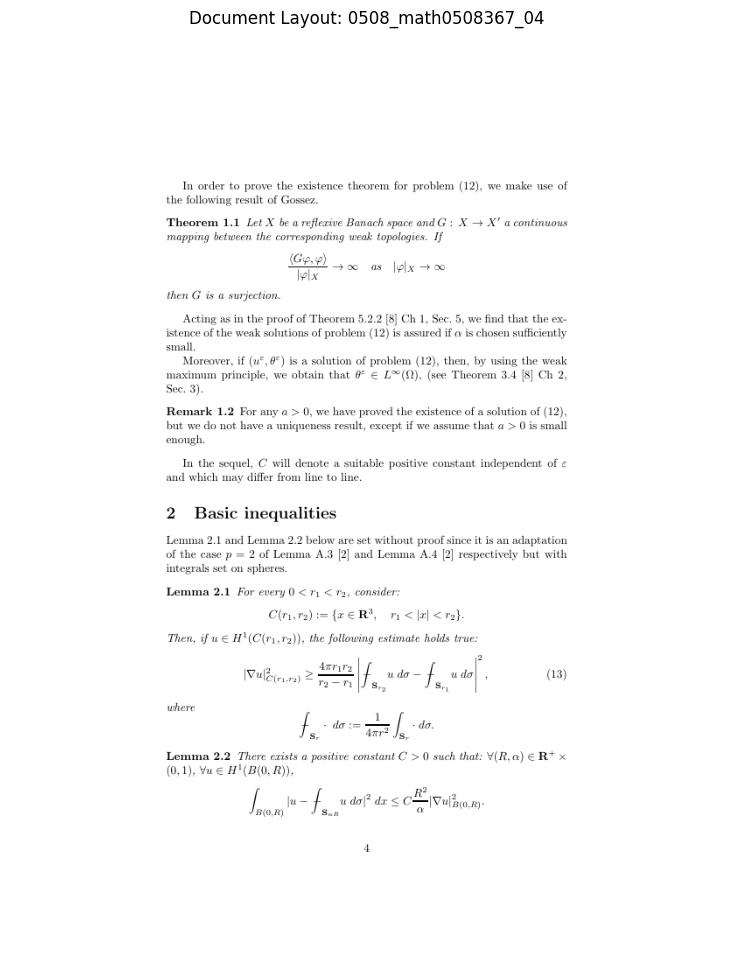


Markdown Preview:
--------------------------------------------------------------------------------
In order to prove the existence theorem for problem (12), we make use of the following result of
Gossez.  **Theorem 1.1**: _Let \(X\) be a reflexive Banach space and \(G:\,X\to X^{\prime}\) a
continuous mapping between the corresponding weak topologies. If_  \[\frac{\langle
G\varphi,\varphi\rangle}{|\varphi|_{X}}\to\infty\quad\mbox{as} \quad|\varphi|_{X}\to\infty\]  _then
\(G\) is a surjection._  Acting as in the proof of Theorem 5.2.2 [8] Ch 1, Sec. 5, we find that the
existence of the weak solutions of problem (12) is assured if \(\alpha\) is chosen sufficiently
small.  Moreover, if \((u^{\varepsilon},\theta^{\varepsilon})\) is a solution of problem (12), then,
by using the weak maximum principle, we obtain that \(\theta^{\varepsilon}\in L^{\infty}(\Omega)\),
(see Theorem 3.4 [8] Ch 2, Sec. 3).  **Remark 1.2**: For any \(a>0\), we have proved the existence
of a solution of (12), but we

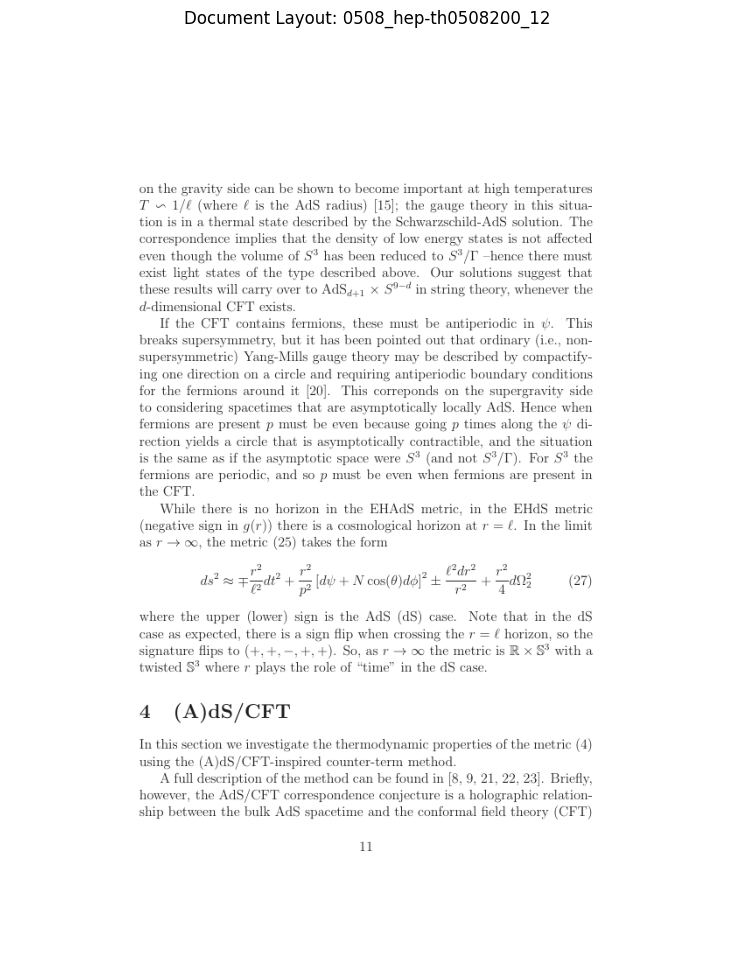


Markdown Preview:
--------------------------------------------------------------------------------
on the gravity side can be shown to become important at high temperatures \(T\backsim 1/\ell\)
(where \(\ell\) is the AdS radius) [15]; the gauge theory in this situation is in a thermal state
described by the Schwarzschild-AdS solution. The correspondence implies that the density of low
energy states is not affected even though the volume of \(S^{3}\) has been reduced to
\(S^{3}/\Gamma\) -hence there must exist light states of the type described above. Our solutions
suggest that these results will carry over to AdS\({}_{d+1}\)\(\times\)\(S^{9-d}\) in string theory,
whenever the \(d\)-dimensional CFT exists.  If the CFT contains fermions, these must be antiperiodic
in \(\psi\). This breaks supersymmetry, but it has been pointed out that ordinary (i.e.,
nonsupersymmetric) Yang-Mills gauge theory may be described by compactifying one direction on a
circle and requiring antiperiodic boundar

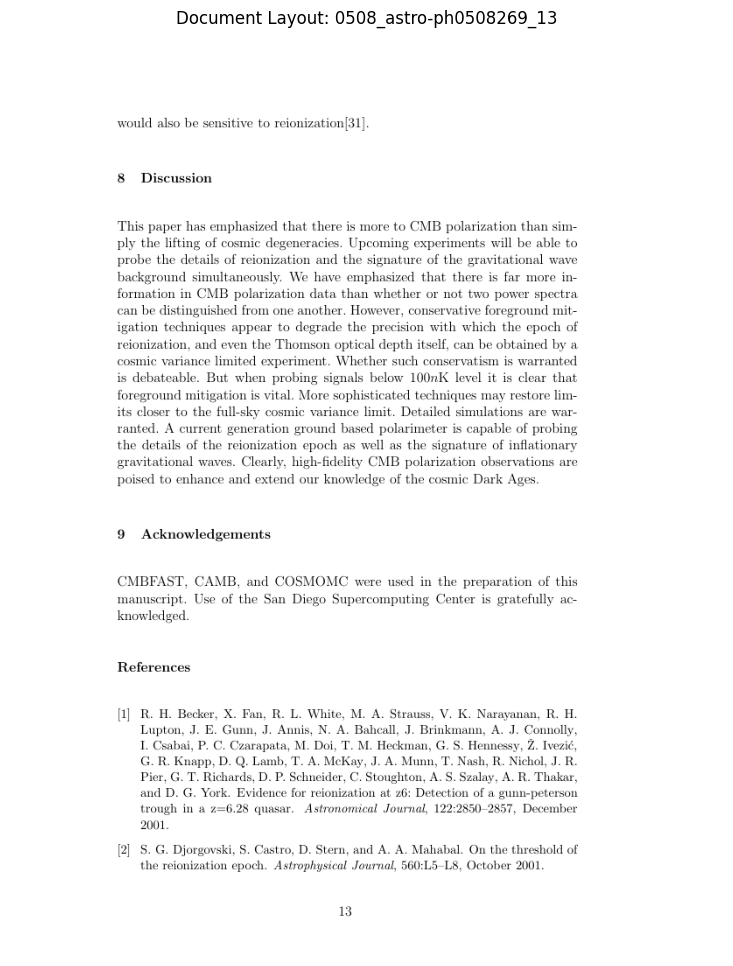


Markdown Preview:
--------------------------------------------------------------------------------
would also be sensitive to reionization[31].  ## 8 Discussion  This paper has emphasized that there
is more to CMB polarization than simply the lifting of cosmic degeneracies. Upcoming experiments
will be able to probe the details of reionization and the signature of the gravitational wave
background simultaneously. We have emphasized that there is far more information in CMB polarization
data than whether or not two power spectra can be distinguished from one another. However,
conservative foreground mitigation techniques appear to degrade the precision with which the epoch
of reionization, and even the Thomson optical depth itself, can be obtained by a cosmic variance
limited experiment. Whether such conservatism is warranted is debateable. But when probing signals
below \(100n\)K level it is clear that foreground mitigation is vital. More sophisticated techniques
may restore limits cl

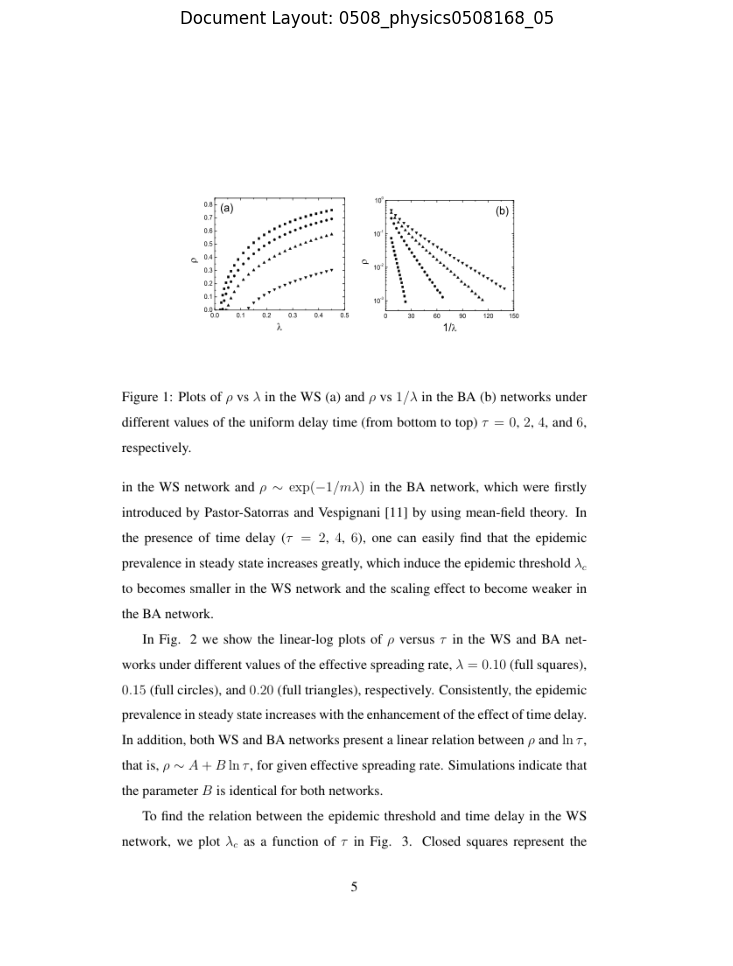


Markdown Preview:
--------------------------------------------------------------------------------
in the WS network and \(\rho\sim\exp(-1/m\lambda)\) in the BA network, which were firstly introduced
by Pastor-Satorras and Vespignani [11] by using mean-field theory. In the presence of time delay
(\(\tau=2\), \(4\), \(6\)), one can easily find that the epidemic prevalence in steady state
increases greatly, which induce the epidemic threshold \(\lambda_{c}\) to becomes smaller in the WS
network and the scaling effect to become weaker in the BA network.    In Fig. 2 we show the linear-
log plots of \(\rho\) versus \(\tau\) in the WS and BA networks under different values of the
effective spreading rate, \(\lambda=0.10\) (full squares), \(0.15\) (full circles), and \(0.20\)
(full triangles), respectively. Consistently, the epidemic prevalence in steady state increases with
the enhancement of the effect of time delay. In addition, both WS and BA networks present a linear
relation between \

In [59]:
import textwrap

def inspect_pairs(pairs, num_samples=5):
    print(f"Total pairs available: {len(pairs)}")
    samples = random.sample(pairs, min(num_samples, len(pairs)))

    for idx, sample in enumerate(samples):
        img_path, markdown, stem = sample['image_path'], sample['markdown'], sample['stem']

        print("\n" + "="*80)
        print(f"Sample {idx+1} | Document ID: {stem}")
        print(f"Image Path: {img_path}")
        print("="*80)

        img = Image.open(img_path)
        w, h = img.size
        print(f"\nImage: {w}x{h}px  Aspect ratio: {w/h:.2f}")

        plt.figure(figsize=(10, 12))
        plt.imshow(img)
        plt.title(f"Document Layout: {stem}")
        plt.axis("off")
        plt.show()

        print("\nMarkdown Preview:")
        print("-"*80)
        print(textwrap.fill(markdown[:1200], width=100))
        print("-"*80)

        lines = markdown.splitlines()
        headings     = [l for l in lines if l.strip().startswith("#")]
        bullets      = [l for l in lines if l.strip().startswith(("-", "*"))]
        table_rows   = [l for l in lines if "|" in l]

        print(f"\nStructure: {len(lines)} lines | {len(headings)} headings | {len(bullets)} bullets | {len(table_rows)} table rows | {len(markdown)} chars")
        if headings:
            for h in headings[:3]:
                print(f"  {h}")

inspect_pairs(all_pairs, num_samples=5)

---
## Part 2: Data Preparation — ChatML Format

In [60]:
INSTRUCTION_PROMPT = (
    "You are a document parser. Convert the document image into well-structured markdown. "
    "Preserve all headings, paragraphs, lists, tables, equations, and formatting. "
    "Output only the markdown content with no extra commentary."
)

def create_chatml_sample(image_path, markdown_target):
    return [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image_path},
                {"type": "text",  "text": INSTRUCTION_PROMPT}
            ]
        },
        {
            "role": "assistant",
            "content": markdown_target
        }
    ]

chatml_data = [
    {
        'messages':   create_chatml_sample(p['image_path'], p['markdown']),
        'image_path': p['image_path'],
        'markdown':   p['markdown'],
        'stem':       p['stem']
    }
    for p in all_pairs
]

print(f"ChatML dataset created: {len(chatml_data)} samples")
print("\nExample ChatML structure:")
print(json.dumps({
    'role': 'user',
    'content': [
        {'type': 'image', 'image': '<image_path>'},
        {'type': 'text',  'text':  chatml_data[0]['messages'][0]['content'][1]['text'][:80] + '...'}
    ]
}, indent=2))

ChatML dataset created: 14206 samples

Example ChatML structure:
{
  "role": "user",
  "content": [
    {
      "type": "image",
      "image": "<image_path>"
    },
    {
      "type": "text",
      "text": "You are a document parser. Convert the document image into well-structured markd..."
    }
  ]
}


---
## Part 3: QLoRA Fine-Tuning Setup

In [61]:
MODEL_NAME  = "Qwen/Qwen2-VL-2B-Instruct"
OUTPUT_DIR  = "./qwen2vl-qlora-doc2md"
IMAGE_SIZE  = 512

LOAD_IN_4BIT            = True
BNB_4BIT_COMPUTE_DTYPE  = torch.float16
BNB_4BIT_USE_DOUBLE_QUANT = True
BNB_4BIT_QUANT_TYPE     = "nf4"

LORA_RANK           = 16
LORA_ALPHA          = 32
LORA_DROPOUT        = 0.05
LORA_TARGET_MODULES = ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]

BATCH_SIZE        = 1
NUM_EPOCHS        = 3
GRAD_ACCUMULATION = 8
LEARNING_RATE     = 1e-4
MAX_SEQ_LENGTH    = 1024
WARMUP_RATIO      = 0.05
WEIGHT_DECAY      = 0.01
SAVE_STEPS        = 50
EVAL_STEPS        = 50
LOGGING_STEPS     = 10

print("Training configuration:")
for k, v in {
    "Model": MODEL_NAME, "Quantization": "4-bit nf4",
    "LoRA rank": LORA_RANK, "LoRA alpha": LORA_ALPHA,
    "Epochs": NUM_EPOCHS, "Batch size": BATCH_SIZE,
    "Grad accumulation": GRAD_ACCUMULATION,
    "Effective batch": BATCH_SIZE * GRAD_ACCUMULATION,
    "Learning rate": LEARNING_RATE, "Image size": f"{IMAGE_SIZE}px",
    "Max seq length": MAX_SEQ_LENGTH
}.items():
    print(f"  {k:<22}: {v}")

Training configuration:
  Model                 : Qwen/Qwen2-VL-2B-Instruct
  Quantization          : 4-bit nf4
  LoRA rank             : 16
  LoRA alpha            : 32
  Epochs                : 3
  Batch size            : 1
  Grad accumulation     : 8
  Effective batch       : 8
  Learning rate         : 0.0001
  Image size            : 512px
  Max seq length        : 1024


---
## Part 4: Dataset Subsetting (80/20 Split)

In [62]:
import random
from sklearn.model_selection import train_test_split

MAX_SAMPLES = 500   


random.shuffle(chatml_data)
subset_data = chatml_data[:min(len(chatml_data), MAX_SAMPLES)]

train_data, val_data = train_test_split(subset_data, test_size=0.2, random_state=42)

print(f"Total subset:  {len(subset_data)}")
print(f"Train:         {len(train_data)} (80%)")
print(f"Validation:    {len(val_data)} (20%)")
steps = (len(train_data) // (BATCH_SIZE * GRAD_ACCUMULATION)) * NUM_EPOCHS
print(f"Optimizer steps: {steps}  (grad_accum={GRAD_ACCUMULATION}, epochs={NUM_EPOCHS})")



Total subset:  500
Train:         400 (80%)
Validation:    100 (20%)
Optimizer steps: 150  (grad_accum=8, epochs=3)


In [63]:
print(f"Loading processor from {MODEL_NAME}...")
processor = AutoProcessor.from_pretrained(MODEL_NAME, trust_remote_code=True)
processor.tokenizer.padding_side = 'right'
print(f"Processor type: {type(processor).__name__}")
print(f"Vocab size:     {processor.tokenizer.vocab_size}")

Loading processor from Qwen/Qwen2-VL-2B-Instruct...
Processor type: Qwen2VLProcessor
Vocab size:     151643


In [64]:
import os, importlib
import torch
from transformers import BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(
    load_in_4bit=LOAD_IN_4BIT,
    bnb_4bit_quant_type=BNB_4BIT_QUANT_TYPE,
    bnb_4bit_compute_dtype=BNB_4BIT_COMPUTE_DTYPE,
    bnb_4bit_use_double_quant=BNB_4BIT_USE_DOUBLE_QUANT,
    llm_int8_skip_modules=["model.visual", "lm_head"],  
)

print("BitsAndBytes config:")
print(f"  4-bit:        {bnb_config.load_in_4bit}")
print(f"  Quant type:   {bnb_config.bnb_4bit_quant_type}")
print(f"  Compute dtype:{bnb_config.bnb_4bit_compute_dtype}")
print(f"  Skip modules: {bnb_config.llm_int8_skip_modules}")


BitsAndBytes config:
  4-bit:        True
  Quant type:   nf4
  Compute dtype:torch.float16
  Skip modules: ['model.visual', 'lm_head']


In [65]:
print(f"Loading {MODEL_NAME} in 4-bit quantized form (visual encoder)...")

base_model = Qwen2VLForConditionalGeneration.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",         
    trust_remote_code=True,
    torch_dtype=torch.float16,
    attn_implementation=(
        "flash_attention_2"
        if torch.cuda.is_available() and importlib.util.find_spec("flash_attn") is not None
        else "eager"
    ),
)


vis_dtypes = {p.dtype for p in base_model.model.visual.parameters()}
print(f"Visual encoder dtypes: {vis_dtypes}  (must contain torch.float16)")

total_params = sum(p.numel() for p in base_model.parameters())
print(f"Model type:       {type(base_model).__name__}")
print(f"Total parameters: {total_params:,} ({total_params/1e9:.2f}B)")


Loading Qwen/Qwen2-VL-2B-Instruct in 4-bit quantized form (visual encoder)...


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

Visual encoder dtypes: {torch.float16}  (must contain torch.float16)
Model type:       Qwen2VLForConditionalGeneration
Total parameters: 1,553,887,744 (1.55B)


In [66]:
lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=LORA_RANK,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    target_modules=LORA_TARGET_MODULES,
    bias="none",
    inference_mode=False
)

model = get_peft_model(base_model, lora_config)
model.print_trainable_parameters()

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"\nTrainable: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")

trainable params: 18,464,768 || all params: 2,227,450,368 || trainable%: 0.8290

Trainable: 18,464,768 / 1,572,352,512 (1.17%)


In [79]:
import random
from PIL import Image
from torch.utils.data import Dataset

class DocumentMarkdownDataset(Dataset):

    def __init__(self, data, processor, image_size=512, max_length=1024):
        self.data       = data
        self.processor  = processor
        self.image_size = image_size
        self.max_length = max_length

        
        self.im_start_id = self.processor.tokenizer.convert_tokens_to_ids("<|im_start|>")

    def __len__(self):
        return len(self.data)

    def resize_image(self, image_path):
        img = Image.open(image_path).convert('RGB')
        img.thumbnail((self.image_size, self.image_size), Image.LANCZOS)
        background = Image.new('RGB', (self.image_size, self.image_size), (255, 255, 255))
        background.paste(img, ((self.image_size - img.width) // 2, (self.image_size - img.height) // 2))
        return background

    def _find_assistant_start(self, input_ids):
        positions = (input_ids == self.im_start_id).nonzero(as_tuple=True)[0]
        if len(positions) < 2:
          
            return 0

        last_im_start = positions[-1].item()

       
        newline_id = self.processor.tokenizer.convert_tokens_to_ids("\n")
        mask_end = last_im_start
        for i in range(last_im_start + 1, min(last_im_start + 10, len(input_ids))):
            mask_end = i
            if input_ids[i].item() == newline_id:
                break

        return mask_end + 1  

    def __getitem__(self, idx):
        sample = self.data[idx]

        try:
            image = self.resize_image(sample['image_path'])
        except Exception as e:
            print(f"Skipping corrupt image {sample['image_path']}: {e}")
            return self.__getitem__(random.randint(0, len(self.data) - 1))

        text = self.processor.apply_chat_template(
            sample['messages'], tokenize=False, add_generation_prompt=False
        )
        inputs = self.processor(
            text=[text], images=[image],
            padding="max_length", truncation=True,
            max_length=self.max_length, return_tensors="pt"
        )
        inputs = {
            k: v.squeeze(0) if k not in ('pixel_values', 'image_grid_thw') else v
            for k, v in inputs.items()
        }

        # --- NEW MASKING LOGIC ---
        labels = inputs['input_ids'].clone()
        
        # 1. Mask the padding tokens
        pad_token_id = self.processor.tokenizer.pad_token_id or 151643
        labels[labels == pad_token_id] = -100
        
        # 2. Mask the instruction prompt
        im_start_id = self.processor.tokenizer.convert_tokens_to_ids("<|im_start|>")
        positions = (inputs['input_ids'] == im_start_id).nonzero(as_tuple=True)[0]
        if len(positions) > 0:
            last_im_start = positions[-1].item()
            newline_id = self.processor.tokenizer.convert_tokens_to_ids("\n")
            mask_end = last_im_start
            # Find the \n immediately after <|im_start|>assistant
            for i in range(last_im_start, min(last_im_start + 5, len(inputs['input_ids']))):
                if inputs['input_ids'][i].item() == newline_id:
                    mask_end = i
                    break
            labels[:mask_end + 1] = -100
            
        inputs['labels'] = labels
        # -------------------------

        return inputs



train_dataset = DocumentMarkdownDataset(train_data, processor, IMAGE_SIZE, MAX_SEQ_LENGTH)
val_dataset   = DocumentMarkdownDataset(val_data,   processor, IMAGE_SIZE, MAX_SEQ_LENGTH)

print(f"Train dataset: {len(train_dataset)} samples")
print(f"Val dataset:   {len(val_dataset)} samples")

sample = train_dataset[0]
print(f"\ninput_ids shape:    {sample['input_ids'].shape}")
print(f"attention_mask:     {sample['attention_mask'].shape}")
print(f"pixel_values:       {sample['pixel_values'].shape}")

n_masked = (sample['labels'] == -100).sum().item()
n_total  = sample['labels'].shape[0]
print(f"Labels masked:      {n_masked} / {n_total}  ({100*n_masked/n_total:.1f}% prompt, {100*(n_total-n_masked)/n_total:.1f}% answer)")

Train dataset: 400 samples
Val dataset:   100 samples

input_ids shape:    torch.Size([1024])
attention_mask:     torch.Size([1024])
pixel_values:       torch.Size([1296, 1176])
Labels masked:      384 / 1024  (37.5% prompt, 62.5% answer)


In [73]:
def collate_fn(batch):

    result = {
        'input_ids': torch.stack([b['input_ids'] for b in batch]),
        'attention_mask': torch.stack([b['attention_mask'] for b in batch]),
        'labels': torch.stack([b['labels'] for b in batch]),
    }
    
    if 'pixel_values' in batch[0]:
        result['pixel_values'] = torch.cat([b['pixel_values'] for b in batch], dim=0)
    if 'image_grid_thw' in batch[0]:
        result['image_grid_thw'] = torch.cat([b['image_grid_thw'] for b in batch], dim=0)
        
    return result

In [80]:
from transformers import TrainerCallback

class PrintLossCallback(TrainerCallback):
    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs is not None:
            if "loss" in logs:
                print(f" >> Step {state.global_step} | train_loss={logs['loss']:.4f}")
            if "eval_loss" in logs:
                print(f" >> Step {state.global_step} | eval_loss={logs['eval_loss']:.4f}")


In [81]:
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUMULATION,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    warmup_steps=int(0.05 * (len(train_dataset) // (BATCH_SIZE * GRAD_ACCUMULATION)) * NUM_EPOCHS),
    lr_scheduler_type="cosine",
    optim="paged_adamw_8bit",
    fp16=True,
    bf16=False,
    eval_strategy="steps",
    eval_steps=EVAL_STEPS,
    save_strategy="steps",
    save_steps=SAVE_STEPS,
    save_total_limit=2,
    load_best_model_at_end=False,
    logging_steps=LOGGING_STEPS,
    report_to="none",
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},
    dataloader_pin_memory=False,
    remove_unused_columns=False,

)

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=collate_fn,
    callbacks=[PrintLossCallback()]
)


steps_per_epoch = len(train_dataset) // (BATCH_SIZE * GRAD_ACCUMULATION)
print(f"Total training steps: {steps_per_epoch * NUM_EPOCHS}")
print("\nStarting training...")
print("=" * 60)

train_result = trainer.train()

print("=" * 60)
print("Training complete!")
print(f"Runtime:         {train_result.metrics.get('train_runtime', 0):.0f}s")


Total training steps: 150

Starting training...


Step,Training Loss,Validation Loss


Skipping corrupt image /kaggle/input/datasets/zphilip/nougat-training-dataset-example/0508/math0508342/21.png: cannot identify image file '/kaggle/input/datasets/zphilip/nougat-training-dataset-example/0508/math0508342/21.png'
 >> Step 10 | train_loss=0.0000


In [ ]:
train_steps, train_losses = [], []
val_steps, val_losses = [], []

for entry in trainer.state.log_history:
    if "loss" in entry and "eval_loss" not in entry:
        train_steps.append(entry["step"])
        train_losses.append(entry["loss"])
    if "eval_loss" in entry:
        val_steps.append(entry["step"])
        val_losses.append(entry["eval_loss"])

# Filter out nan from val losses
val_clean = [(s, l) for s, l in zip(val_steps, val_losses) if l == l]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training & Validation Loss', fontsize=13, fontweight='bold')

ax = axes[0]
if train_losses:
    ax.plot(train_steps, train_losses, color='steelblue', linewidth=2, marker='o', markersize=4)
ax.set_title('Training Loss')
ax.set_xlabel('Step')
ax.set_ylabel('Loss')
ax.grid(True, alpha=0.3)

ax = axes[1]
if val_clean:
    vs, vl = zip(*val_clean)
    ax.plot(vs, vl, color='darkorange', linewidth=2, marker='o', markersize=4)
ax.set_title('Validation Loss')
ax.set_xlabel('Step')
ax.set_ylabel('Loss')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()

if train_losses:
    print(f"Train loss range: {min(train_losses):.6f} -> {max(train_losses):.6f}")
if val_clean:
    print(f"Val loss range:   {min(vl for _, vl in val_clean):.6f} -> {max(vl for _, vl in val_clean):.6f}")

In [ ]:
FINAL_MODEL_DIR = "./qwen2vl-qlora-final"
trainer.save_model(FINAL_MODEL_DIR)
processor.save_pretrained(FINAL_MODEL_DIR)
print(f"Model saved to {FINAL_MODEL_DIR}")

---
## Part 5: Markdown Generation

In [ ]:
def generate_markdown(model, processor, image_path,
                      max_new_tokens=256, image_size=512):
    img = Image.open(image_path).convert('RGB')
    img.thumbnail((image_size, image_size), Image.LANCZOS)
    bg = Image.new('RGB', (image_size, image_size), (255, 255, 255))
    bg.paste(img, ((image_size - img.width) // 2,
                   (image_size - img.height) // 2))

    messages = [{"role": "user", "content": [
        {"type": "image", "image": image_path},
        {"type": "text",  "text":  INSTRUCTION_PROMPT}
    ]}]
    text   = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True)
    device = next(model.parameters()).device
    inputs = processor(text=[text], images=[bg],
                       return_tensors="pt").to(device)

    with torch.inference_mode():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            use_cache=True,
        )

    input_len = inputs['input_ids'].shape[1]
    generated = processor.tokenizer.decode(
        output_ids[0][input_len:], skip_special_tokens=True)
    return generated.strip()

print("generate_markdown() updated (max_new_tokens=256, inference_mode).")


In [ ]:
model.eval()
val_results = []

print(f"Generating markdown for {len(val_data)} validation samples...")
for sample in tqdm(val_data):
    generated = generate_markdown(model, processor, sample['image_path'])
    val_results.append({
        'stem':         sample['stem'],
        'image_path':   sample['image_path'],
        'ground_truth': sample['markdown'],
        'generated':    generated,
        'type':         'validation'
    })

print(f"Generated {len(val_results)} validation outputs.")

In [ ]:
def visualize_result(result, title_prefix="", save_path=None):
    fig, axes = plt.subplots(1, 3, figsize=(20, 10))
    fig.suptitle(f"{title_prefix}Document: {result['stem']}", fontsize=12, fontweight='bold')

    img = Image.open(result['image_path'])
    axes[0].imshow(img); axes[0].set_title('Input Image'); axes[0].axis('off')

    axes[1].text(0.02, 0.98, result['ground_truth'][:1500],
                 transform=axes[1].transAxes, fontsize=7, verticalalignment='top',
                 fontfamily='monospace', wrap=True)
    axes[1].set_title('Ground Truth Markdown'); axes[1].axis('off')
    axes[1].set_facecolor('#f9f9f9')

    axes[2].text(0.02, 0.98, result['generated'][:1500],
                 transform=axes[2].transAxes, fontsize=7, verticalalignment='top',
                 fontfamily='monospace', wrap=True)
    axes[2].set_title('Generated Markdown'); axes[2].axis('off')
    axes[2].set_facecolor('#f0fff0')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()

print("visualize_result() defined.")

In [ ]:
print("Visualizing first 3 validation results...")
for i, result in enumerate(val_results[:3]):
    visualize_result(result, title_prefix=f"[Val {i+1}/3] ", save_path=f"val_result_{i+1}.png")

---
## Part 6: Testing Task — Training & Unseen Images

In [ ]:
train_test_samples  = random.sample(train_data, 3)
unseen_stems        = {s['stem'] for s in train_data} | {s['stem'] for s in val_data}
unseen_candidates   = [p for p in all_pairs if p['stem'] not in unseen_stems]
unseen_test_samples = random.sample(unseen_candidates, min(3, len(unseen_candidates)))

print(f"Training test samples: {[s['stem'] for s in train_test_samples]}")
print(f"Unseen test samples:   {[s['stem'] for s in unseen_test_samples]}")

In [ ]:
train_results, unseen_results = [], []

print("Generating for 3 training images...")
for sample in tqdm(train_test_samples):
    generated = generate_markdown(model, processor, sample['image_path'])
    train_results.append({
        'stem': sample['stem'], 'image_path': sample['image_path'],
        'ground_truth': sample['markdown'], 'generated': generated, 'type': 'training'
    })

print("Generating for 3 unseen images...")
for sample in tqdm(unseen_test_samples):
    generated = generate_markdown(model, processor, sample['image_path'])
    unseen_results.append({
        'stem': sample['stem'], 'image_path': sample['image_path'],
        'ground_truth': sample['markdown'], 'generated': generated, 'type': 'unseen'
    })

print("Done.")

In [ ]:
print("Training image results:")
for i, r in enumerate(train_results):
    visualize_result(r, title_prefix=f"[Train {i+1}/3] ", save_path=f"train_result_{i+1}.png")

print("Unseen image results:")
for i, r in enumerate(unseen_results):
    visualize_result(r, title_prefix=f"[Unseen {i+1}/3] ", save_path=f"unseen_result_{i+1}.png")

---
## Comparison: Actual vs Predicted

In [ ]:
def compute_simple_similarity(gt, pred):
    gt_words   = set(gt.lower().split())
    pred_words = set(pred.lower().split())
    if not gt_words and not pred_words:
        return 1.0
    return len(gt_words & pred_words) / len(gt_words | pred_words)

all_test_results = train_results + unseen_results + val_results

rows = []
for r in all_test_results:
    sim = compute_simple_similarity(r['ground_truth'], r['generated'])
    rows.append({
        'type':        r['type'],
        'stem':        r['stem'],
        'gt_length':   len(r['ground_truth']),
        'gen_length':  len(r['generated']),
        'jaccard_sim': round(sim, 3),
    })

df_compare = pd.DataFrame(rows)
print(df_compare[['type', 'stem', 'gt_length', 'gen_length', 'jaccard_sim']].to_string(index=False))
print(f"\nAverage Jaccard similarity: {df_compare['jaccard_sim'].mean():.3f}")

In [ ]:
print("Detailed actual vs predicted (first 3 val samples)")
print("=" * 80)
for i, r in enumerate(val_results[:3]):
    sim = compute_simple_similarity(r['ground_truth'], r['generated'])
    print(f"\n--- Validation Sample {i+1}: {r['stem']} | Jaccard: {sim:.3f} ---")
    print("[Actual — first 300 chars]")
    print(r['ground_truth'][:300])
    print("[Predicted — first 300 chars]")
    print(r['generated'][:300])
    print("-" * 40)

---
## Summary Visualization

In [ ]:
sims = df_compare['jaccard_sim'].tolist()
types = df_compare['type'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Fine-Tuning Summary — QLoRA Qwen2-VL-2B-Instruct: Document → Markdown',
             fontsize=13, fontweight='bold')

ax = axes[0, 0]
if trainer.train_loss_history:
    ax.plot([h['step'] for h in trainer.train_loss_history],
            [h['loss'] for h in trainer.train_loss_history], color='steelblue', linewidth=2)
ax.set_title('Training Loss'); ax.set_xlabel('Step'); ax.set_ylabel('Loss'); ax.grid(True, alpha=0.3)

ax = axes[0, 1]
if trainer.val_loss_history:
    ax.plot([h['step'] for h in trainer.val_loss_history],
            [h['loss'] for h in trainer.val_loss_history], color='darkorange', linewidth=2)
ax.set_title('Validation Loss'); ax.set_xlabel('Step'); ax.set_ylabel('Loss'); ax.grid(True, alpha=0.3)

ax = axes[0, 2]
colors = ['steelblue' if t == 'training' else ('darkorange' if t == 'unseen' else 'mediumseagreen') for t in types]
ax.bar(range(len(sims)), sims, color=colors, edgecolor='white')
ax.axhline(y=np.mean(sims), color='red', linestyle='--', alpha=0.7, label=f'Mean: {np.mean(sims):.3f}')
ax.set_xticks(range(len(sims)))
ax.set_xticklabels([f"{t[0].upper()}{i+1}" for i, t in enumerate(types)], fontsize=9)
ax.set_title('Jaccard Similarity'); ax.set_ylabel('Score'); ax.set_ylim(0, 1); ax.legend(fontsize=8)
ax.grid(True, alpha=0.2, axis='y')

ax = axes[1, 0]
x = np.arange(len(df_compare)); w = 0.35
ax.bar(x - w/2, df_compare['gt_length'],  w, label='Ground Truth', color='darkgreen',  alpha=0.7)
ax.bar(x + w/2, df_compare['gen_length'], w, label='Generated',    color='cornflowerblue', alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels([r['stem'][:8] for r in all_test_results], rotation=30, fontsize=8)
ax.set_title('Output Length: Actual vs Generated'); ax.set_ylabel('Characters'); ax.legend(fontsize=8)
ax.grid(True, alpha=0.2, axis='y')

ax = axes[1, 1]; ax.axis('off')
ax.text(0.05, 0.95,
    f"Model: Qwen2-VL-2B-Instruct\n"
    f"Quantization: 4-bit nf4\n"
    f"LoRA rank: {LORA_RANK}   alpha: {LORA_ALPHA}\n"
    f"Epochs: {NUM_EPOCHS}\n"
    f"Batch size: {BATCH_SIZE}   grad accum: {GRAD_ACCUMULATION}\n"
    f"Effective batch: {BATCH_SIZE * GRAD_ACCUMULATION}\n"
    f"Learning rate: {LEARNING_RATE}\n"
    f"Image size: {IMAGE_SIZE}px\n"
    f"Train samples: {len(train_data)}   Val: {len(val_data)}",
    transform=ax.transAxes, fontsize=10, verticalalignment='top', fontfamily='monospace',
    bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='goldenrod', alpha=0.9))
ax.set_title('Training Configuration', fontweight='bold')

ax = axes[1, 2]; ax.axis('off')
ax.text(0.05, 0.95,
    f"Results Summary\n{'─'*28}\n"
    f"Val samples generated:  {len(val_results)}\n"
    f"Train test samples:     3\n"
    f"Unseen test samples:    3\n"
    f"Avg Jaccard similarity: {np.mean(sims):.3f}\n"
    f"Avg GT length:          {int(df_compare['gt_length'].mean())} chars\n"
    f"Avg generated length:   {int(df_compare['gen_length'].mean())} chars\n"
    f"Model saved to:\n  {FINAL_MODEL_DIR}",
    transform=ax.transAxes, fontsize=10, verticalalignment='top', fontfamily='monospace',
    bbox=dict(boxstyle='round', facecolor='lightcyan', edgecolor='steelblue', alpha=0.9))
ax.set_title('Results Summary', fontweight='bold')

plt.tight_layout()
plt.savefig('full_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved full_summary.png")

In [ ]:
print("All outputs:")
for fname in [
    'training_loss_curves.png',
    'train_result_1.png', 'train_result_2.png', 'train_result_3.png',
    'unseen_result_1.png', 'unseen_result_2.png', 'unseen_result_3.png',
    'val_result_1.png', 'val_result_2.png', 'val_result_3.png',
    'full_summary.png'
]:

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"\nModel: Qwen2-VL-2B-Instruct + QLoRA")
print(f"Task:  Document image → Markdown")
print(f"Trainable params: {trainable:,} ({100*trainable/total:.2f}% of {total:,})")
print(f"Avg Jaccard similarity: {np.mean(sims):.3f}")